<div style="background: #061512; border: 1px solid #112F29; padding: 40px; border-radius: 12px; margin-bottom: 28px; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; box-shadow: 0 10px 15px -3px rgba(0, 0, 0, 0.4); max-width: 100%; box-sizing: border-box;">

<div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid #112F29; padding-bottom: 16px; margin-bottom: 24px; flex-wrap: wrap; gap: 12px;">
<div style="display: flex; gap: 8px; align-items: center;">
<span style="background: rgba(16, 185, 129, 0.15); color: #34D399; font-size: 0.75rem; font-weight: 600; padding: 4px 10px; border-radius: 4px; letter-spacing: 0.5px; text-transform: uppercase; border: 1px solid rgba(16, 185, 129, 0.25);">Case Study</span>
<span style="background: #112F29; color: #94A3B8; font-size: 0.75rem; font-weight: 600; padding: 4px 10px; border-radius: 4px; border: 1px solid #14532D; font-family: monospace;">supervised-learning . classification</span>
</div>
<div style="color: #4D7C0F; font-size: 0.78rem; font-family: monospace; font-weight: 500;">METRIC SPACE: CHURN-RISK</div>
</div>

<h1 style="color: #F8FAFC; margin: 0 0 10px 0; font-size: 2.1em; font-weight: 700; letter-spacing: -0.5px; line-height: 1.2;">Olist E-Commerce Retention Analytics</h1>

<p style="color: #A7F3D0; opacity: 0.8; margin: 0 0 28px 0; font-size: 1.05em; font-weight: 400; line-height: 1.6; max-width: 850px;">An end-to-end predictive framework designed to isolate behavioral drivers of customer attrition. This technical report details the extraction of transactional primitives via SQL, cross-validation benchmarking of linear and non-linear classification architectures, and the deployment optimization of risk-scoring models.</p>

<div style="display: flex; gap: 20px; margin-top: 12px; flex-wrap: wrap;">
<div style="background: #0B2521; border-left: 4px solid #10B981; padding: 16px; border-radius: 0 8px 8px 0; flex: 1; min-width: 220px; box-sizing: border-box; border-top: 1px solid #112F29; border-right: 1px solid #112F29; border-bottom: 1px solid #112F29;">
<span style="color: #6EE7B7; opacity: 0.8; font-size: 0.72rem; text-transform: uppercase; letter-spacing: 0.8px; font-weight: 700; display: block; margin-bottom: 6px;">DATASET PRIMITIVE</span>
<span style="color: #F1F5F9; font-weight: 600; font-size: 1rem; display: block;">28,020 Verified Cohorts</span>
<span style="color: #64748B; font-size: 0.75rem; display: block; margin-top: 2px;">SQL Feature-Store Extract</span>
</div>
<div style="background: #0B2521; border-left: 4px solid #34D399; padding: 16px; border-radius: 0 8px 8px 0; flex: 1; min-width: 220px; box-sizing: border-box; border-top: 1px solid #112F29; border-right: 1px solid #112F29; border-bottom: 1px solid #112F29;">
<span style="color: #6EE7B7; opacity: 0.8; font-size: 0.72rem; text-transform: uppercase; letter-spacing: 0.8px; font-weight: 700; display: block; margin-bottom: 6px;">TARGET ATTRIBUTE</span>
<span style="color: #F1F5F9; font-weight: 600; font-size: 1rem; display: block;">Binary Status (y ∈ {0, 1})</span>
<span style="color: #64748B; font-size: 0.75rem; display: block; margin-top: 2px;">0: Churned • 1: Retained</span>
</div>
<div style="background: #0B2521; border-left: 4px solid #A7F3D0; padding: 16px; border-radius: 0 8px 8px 0; flex: 1; min-width: 220px; box-sizing: border-box; border-top: 1px solid #112F29; border-right: 1px solid #112F29; border-bottom: 1px solid #112F29;">
<span style="color: #6EE7B7; opacity: 0.8; font-size: 0.72rem; text-transform: uppercase; letter-spacing: 0.8px; font-weight: 700; display: block; margin-bottom: 6px;">MODEL EVALUATION</span>
<span style="color: #F1F5F9; font-weight: 600; font-size: 1rem; display: block;">LogReg → RF → XGBoost</span>
<span style="color: #64748B; font-size: 0.75rem; display: block; margin-top: 2px;">Stratified 5-Fold Evaluation</span>
</div>
</div>

</div>

---

## Section 1 — Business Problem

Customer churn is one of the most critical challenges in e-commerce. On the OLIST marketplace — Brazil's largest multi-seller online platform — a customer who does not return after their first or second purchase represents a permanent revenue loss.

Research consistently shows that:
- Acquiring a new customer costs **5–7× more** than retaining an existing one
- A **5% improvement in retention** can increase profits by 25–95%
- Churned customers who had a negative experience can damage brand reputation

### What Is Churn in This Context?

> A customer is defined as **churned** if they have not placed a new delivered order within the observation window following their last purchase.

| Label | Meaning |
|---|---|
| `0` | **Churned** — customer did not return |
| `1` | **Retained** — customer made repeat purchases |

### Business Goal

Build a machine learning model that identifies **at-risk customers before they churn**, enabling:
- Targeted retention campaigns (discount vouchers, re-engagement emails)
- Proactive customer success outreach
- Priority support for dissatisfied customers
- Smarter budget allocation toward high-churn-risk segments

### Why This Is Hard

The dataset is **severely imbalanced** — 97.8% of customers churned (first-time buyers who never returned). Standard accuracy is meaningless here. The model must be optimized for **Recall** (catching real churners) and **ROC-AUC** (discriminative ability across thresholds).


---

## Section 2 — Dataset Overview

The feature dataset contains **28,020 customers** with **36 engineered behavioral features** derived from raw OLIST transactional tables via SQL.

### Feature Categories

| Category | Features | Description |
|---|---|---|
| **RFM** | `recency`, `frequency`, `monetary` | Classic retention signals |
| **Recent Activity** | `orders_last_7_days`, `orders_last_30_days`, `orders_last_90_days`, `orders_last_180_days` | Short-window purchase momentum |
| **Monetary Windows** | `monetary_last_30_days`, `monetary_last_90_days` | Recent spending activity |
| **Order Statistics** | `avg_order_value`, `max_order_value`, `min_order_value` | Basket value distribution |
| **Product Behavior** | `total_items`, `avg_items_per_order`, `total_unique_products`, `total_unique_categories` | Breadth of purchasing |
| **Review Behavior** | `avg_review_score`, `min_review_score`, `low_review_ratio` | Customer satisfaction signals |
| **Delivery Experience** | `avg_delivery_delay`, `max_delivery_delay`, `late_delivery_ratio` | Fulfillment quality |
| **Payment** | `avg_installments` | Payment behavior |
| **Temporal** | `weekend_order_ratio`, `customer_lifetime_days` | Shopping pattern features |
| **Derived Ratios** | `recency_ratio`, `purchase_acceleration`, `recent_spend_ratio`, `monetary_per_item` | Engineered behavioral metrics |
| **Target** | `churn_label` | 0 = Churned, 1 = Retained |


---

## Section 3 — SQL-to-Feature Engineering Pipeline

The raw OLIST data lives in relational SQL tables. The feature dataset used in this notebook was produced by a multi-stage SQL pipeline before any Python modeling.

```
Raw OLIST SQL Database
        ↓
SQL Feature Engineering (feature_engineering.sql)
  • Customer-level RFM aggregations
  • Temporal window features (7/30/90/180 day orders)
  • Review and delivery quality metrics
  • Behavioral ratio engineering
  • Churn label definition via observation window
        ↓
Exported Feature CSV
  → data/processed/customer_features.csv
        ↓
Python: EDA → Preprocessing → Modeling
```

### Key SQL Design Decisions

**Temporal labeling** — The churn label was defined using a forward-looking observation window after the feature cutoff date, ensuring no future information leaks into the features (same principle as the OLIST Repeat Customer Prediction project).

**Customer-level aggregation** — All features were rolled up to one row per `customer_unique_id` using `GROUP BY` with window functions, CTEs, and conditional aggregations.

**Feature engineering in SQL** — Ratios like `purchase_acceleration`, `recent_spend_ratio`, and `low_review_ratio` were computed in SQL before export, taking advantage of set-based operations on the full dataset.


---

## Section 4 — Import Libraries


In [1]:
# ── Install imbalanced-learn if needed ────────────────────────────────────────

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import joblib

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Sklearn — Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)

# Sklearn — Pipelines
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer

# Sklearn — Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Sklearn — Feature Selection
from sklearn.feature_selection import SelectFromModel

# Sklearn — Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

# Imbalanced-learn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

# ── Model colour palette ──────────────────────────────────────────────────────
MODEL_COLORS = {
    "Logistic Regression": "#0288d1",
    "Random Forest"      : "#00897b",
    "XGBoost"            : "#e94560",
}

RANDOM_STATE = 42

cwd = Path.cwd().resolve()
NOTEBOOK_DIR = cwd / "notebook" if (cwd / "notebook").exists() else cwd
os.chdir(NOTEBOOK_DIR)

PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebook" else NOTEBOOK_DIR

# ── Create output subfolders for organized results ─────────────────────────
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIRS = [
    OUTPUT_DIR / "eda",
    OUTPUT_DIR / "confusion_matrices",
    OUTPUT_DIR / "roc_curves",
    OUTPUT_DIR / "feature_importance",
    OUTPUT_DIR / "model_comparison",
]
for folder in OUTPUT_DIRS:
    folder.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")
print(f"Working directory: {Path.cwd()}")


Libraries loaded.
Working directory: E:\DATAPLAY\PROJECT\olist-retention-prediction\notebook


---

## Section 5 — Load Data


In [2]:
# ── Load feature dataset ──────────────────────────────────────────────────────
df = pd.read_csv("../data/processed/customer_features.csv")

# Remove any incomplete target rows before modeling.
df = df.dropna(subset=["churn_label"]).copy()
df["churn_label"] = df["churn_label"].astype(int)

df["churn_label"] = 1 - df["churn_label"]  # Invert labels so 0 = Churned, 1 = Retained

print(f"Dataset shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print()

# ── Target encoding confirmation ──────────────────────────────────────────────
print("Target distribution:")
print(df["churn_label"].value_counts())
print()
print("Class proportions:")
print(df["churn_label"].value_counts(normalize=True).round(4))
print()

print("Encoding: 0 = Churned  |  1 = Retained")

Dataset shape : 5,236 rows  ×  37 columns

Target distribution:
churn_label
0    5119
1     117
Name: count, dtype: int64

Class proportions:
churn_label
0    0.9777
1    0.0223
Name: proportion, dtype: float64

Encoding: 0 = Churned  |  1 = Retained


In [3]:
df.head()


,customer_unique_id,recency,frequency,monetary,first_order_date,last_order_date,customer_lifetime_days,days_since_first_purchase,orders_last_7_days,orders_last_30_days,...,avg_installments,weekend_order_ratio,avg_days_between_orders,orders_per_month,spend_per_month,recency_ratio,purchase_acceleration,recent_spend_ratio,monetary_per_item,churn_label
0,0000f46a3911fa3c0805444483337064,221,1,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,221,0,0,...,8.0,0.0,NaN,1.0,86.22,NaN,0.0,0.0,86.22,0
1,0000f6ccb0745a6a4b88665a16c9f078,5,1,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,0,5,1,1,...,4.0,0.0,NaN,1.0,43.62,NaN,1.0,1.0,43.62,0
2,0005e1862207bf6ccc02e4228effd9a0,227,1,150.12,2017-03-04 23:32:12,2017-03-04 23:32:12,0,227,0,0,...,3.0,1.0,NaN,1.0,150.12,NaN,0.0,0.0,150.12,0
3,0006fdc98a402fceb4eb0ee528f6a8d4,91,1,29.00,2017-07-18 09:23:10,2017-07-18 09:23:10,0,91,0,0,...,2.0,0.0,NaN,1.0,29.00,NaN,0.0,0.0,29.00,0
4,000a5ad9c4601d2bbdd9ed765d5213b3,67,1,91.28,2017-08-11 13:45:15,2017-08-11 13:45:15,0,67,0,0,...,3.0,0.0,NaN,1.0,91.28,NaN,0.0,0.0,91.28,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5236 entries, 0 to 5235
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_unique_id         5236 non-null   object 
 1   recency                    5236 non-null   int64  
 2   frequency                  5236 non-null   int64  
 3   monetary                   5236 non-null   float64
 4   first_order_date           5236 non-null   object 
 5   last_order_date            5236 non-null   object 
 6   customer_lifetime_days     5236 non-null   int64  
 7   days_since_first_purchase  5236 non-null   int64  
 8   orders_last_7_days         5236 non-null   int64  
 9   orders_last_30_days        5236 non-null   int64  
 10  orders_last_90_days        5236 non-null   int64  
 11  orders_last_180_days       5236 non-null   int64  
 12  monetary_last_30_days      5236 non-null   float64
 13  monetary_last_90_days      5236 non-null   float64
 1

In [5]:
# ── Missing value profile ─────────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0]

print(f"Features with missing values: {len(missing_df)}")
print()
print(missing_df)
print()
print("→ recency_ratio and avg_days_between_orders are undefined for single-order customers (NaN by design).")
print("→ Will be filled via median imputation inside the pipeline.")


Features with missing values: 2

                         Missing  Missing %
recency_ratio               5166      98.66
avg_days_between_orders     5117      97.73

→ recency_ratio and avg_days_between_orders are undefined for single-order customers (NaN by design).
→ Will be filled via median imputation inside the pipeline.


---

## Section 6 — Data Understanding


In [6]:
# ── Statistical summary ───────────────────────────────────────────────────────
df.describe().round(2).T[["mean", "std", "min", "50%", "max"]]


,mean,std,min,50%,max
recency,118.00,79.29,0.00,107.00,379.00
frequency,1.02,0.17,1.00,1.00,6.00
monetary,168.64,291.91,14.13,106.92,13664.08
customer_lifetime_days,0.69,8.61,0.00,0.00,297.00
days_since_first_purchase,118.69,79.39,0.00,108.00,379.00
orders_last_7_days,0.04,0.19,0.00,0.00,2.00
orders_last_30_days,0.15,0.36,0.00,0.00,2.00
orders_last_90_days,0.43,0.51,0.00,0.00,3.00
orders_last_180_days,0.78,0.45,0.00,1.00,3.00
monetary_last_30_days,26.06,209.72,0.00,0.00,13664.08


In [7]:
# ── Churn rate insight ────────────────────────────────────────────────────────
retained  = (df["churn_label"] == 1).sum()
churned   = (df["churn_label"] == 0).sum()
imbalance = churned / retained

print(f"Churned customers   : {churned:,}  ({churned/len(df)*100:.1f}%)")
print(f"Retained customers  : {retained:,}  ({retained/len(df)*100:.1f}%)")
print(f"Imbalance ratio     : {imbalance:.0f}:1  (churn:retain)")
print()
print("⚠️  This is EXTREME class imbalance.")
print("   Accuracy is a misleading metric — a model predicting all churn achieves 97.8%.")
print("   We will optimize for Recall and ROC-AUC instead.")


Churned customers   : 5,119  (97.8%)
Retained customers  : 117  (2.2%)
Imbalance ratio     : 44:1  (churn:retain)

⚠️  This is EXTREME class imbalance.
   Accuracy is a misleading metric — a model predicting all churn achieves 97.8%.
   We will optimize for Recall and ROC-AUC instead.


---

## Section 7 — Exploratory Data Analysis

EDA focuses on understanding what separates churned from retained customers across key behavioral dimensions.


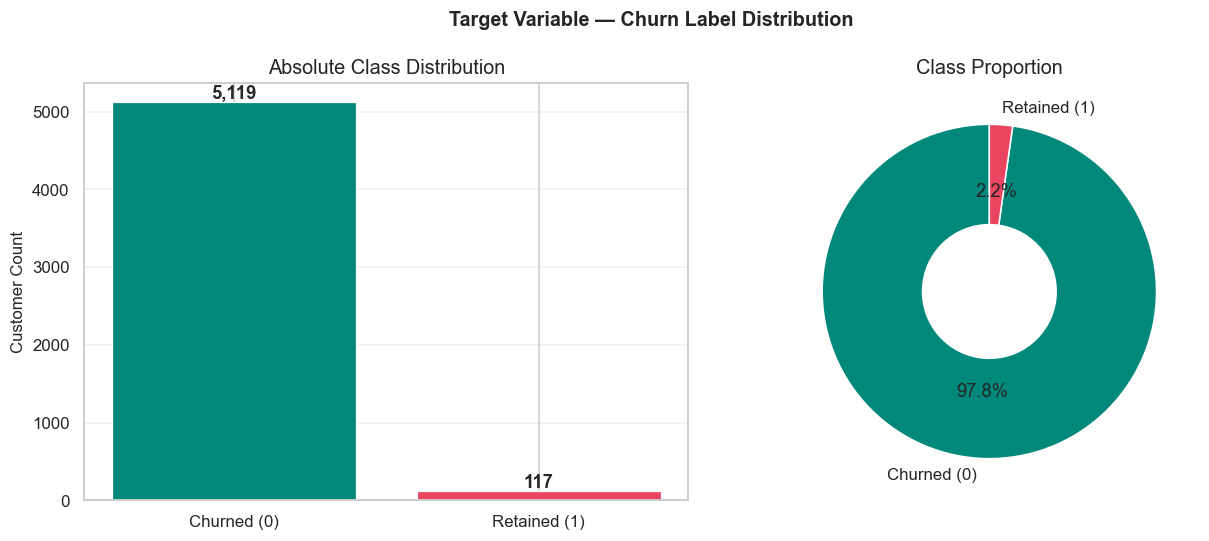

In [8]:
# ── 7.1 Churn distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df["churn_label"].value_counts()
colors = ["#00897b", "#e94560"]

axes[0].bar(["Churned (0)", "Retained (1)"], counts.values,
            color=colors, edgecolor="white", linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Absolute Class Distribution")
axes[0].set_ylabel("Customer Count")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].pie(counts.values, labels=["Churned (0)", "Retained (1)"],
            colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.6))
axes[1].set_title("Class Proportion")

plt.suptitle("Target Variable — Churn Label Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/retained_distribution.png", bbox_inches="tight")
plt.show()


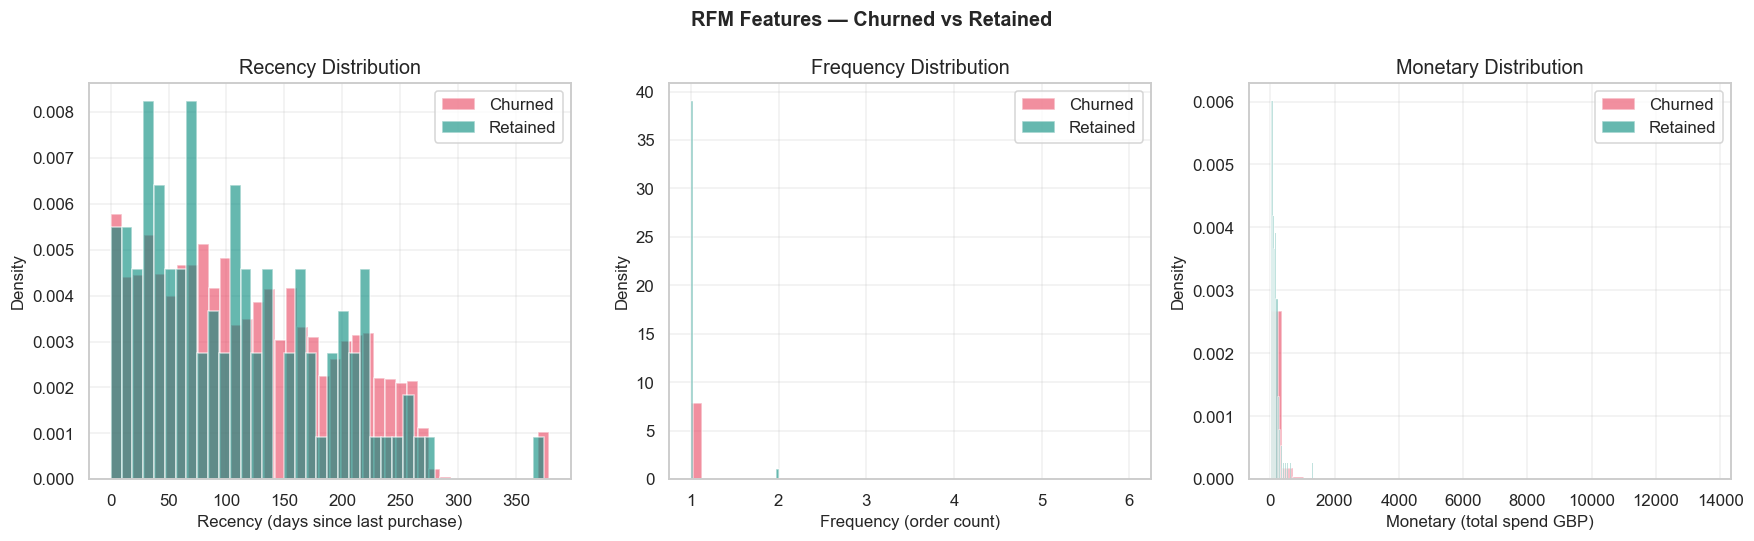

In [9]:
# ── 7.2 RFM comparison: churned vs retained ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rfm_cols = [
    ("recency",   "Recency (days since last purchase)"),
    ("frequency", "Frequency (order count)"),
    ("monetary",  "Monetary (total spend GBP)"),
]

for ax, (col, label) in zip(axes, rfm_cols):
    for churn_val, color, name in [(0, "#e94560", "Churned"), (1, "#00897b", "Retained")]:
        data = df.loc[df["churn_label"] == churn_val, col].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(f"{col.capitalize()} Distribution")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("RFM Features — Churned vs Retained", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/rfm_comparison.png", bbox_inches="tight")
plt.show()


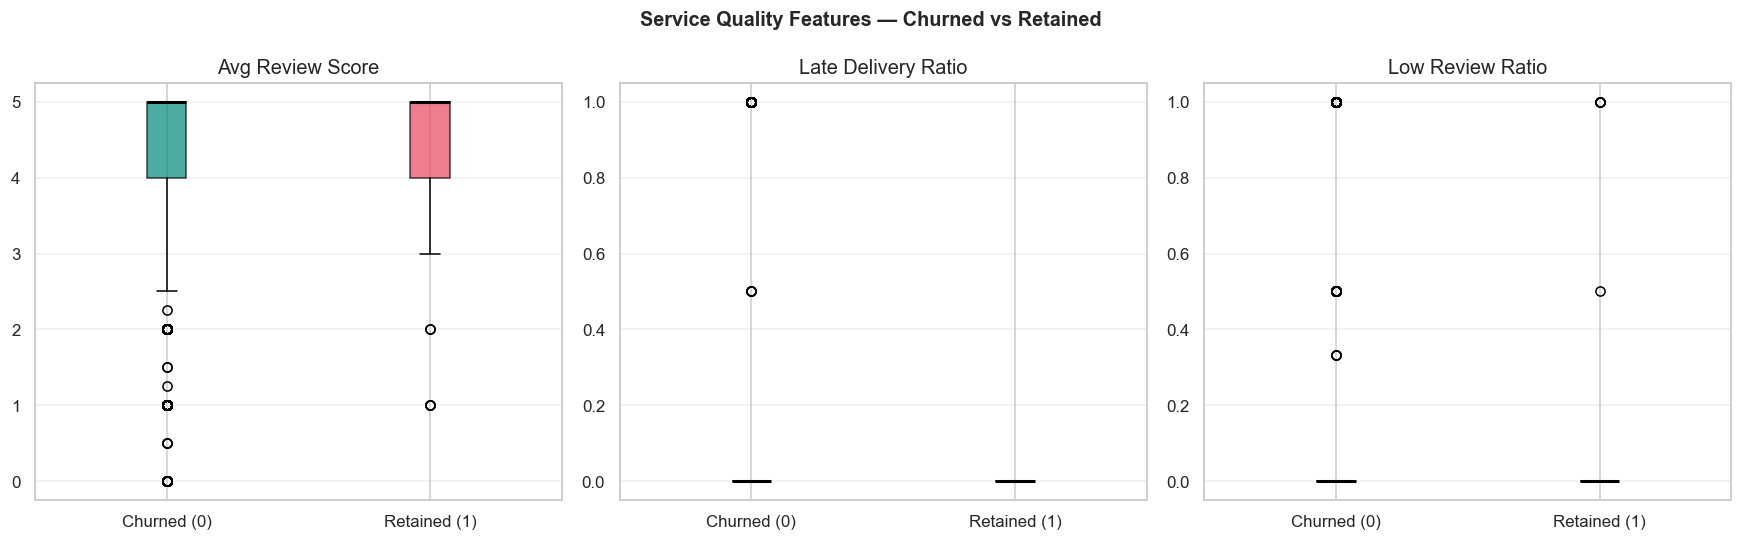

In [10]:
# ── 7.3 Review and delivery quality ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

quality_cols = [
    ("avg_review_score",   "Avg Review Score"),
    ("late_delivery_ratio","Late Delivery Ratio"),
    ("low_review_ratio",   "Low Review Ratio"),
]

for ax, (col, label) in zip(axes, quality_cols):
    retained = df.loc[df["churn_label"] == 0, col].dropna()
    churned  = df.loc[df["churn_label"] == 1, col].dropna()

    bp = ax.boxplot([retained, churned], patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], ["#00897b", "#e94560"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Churned (0)", "Retained (1)"])
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Service Quality Features — Churned vs Retained", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/quality_comparison.png", bbox_inches="tight")
plt.show()


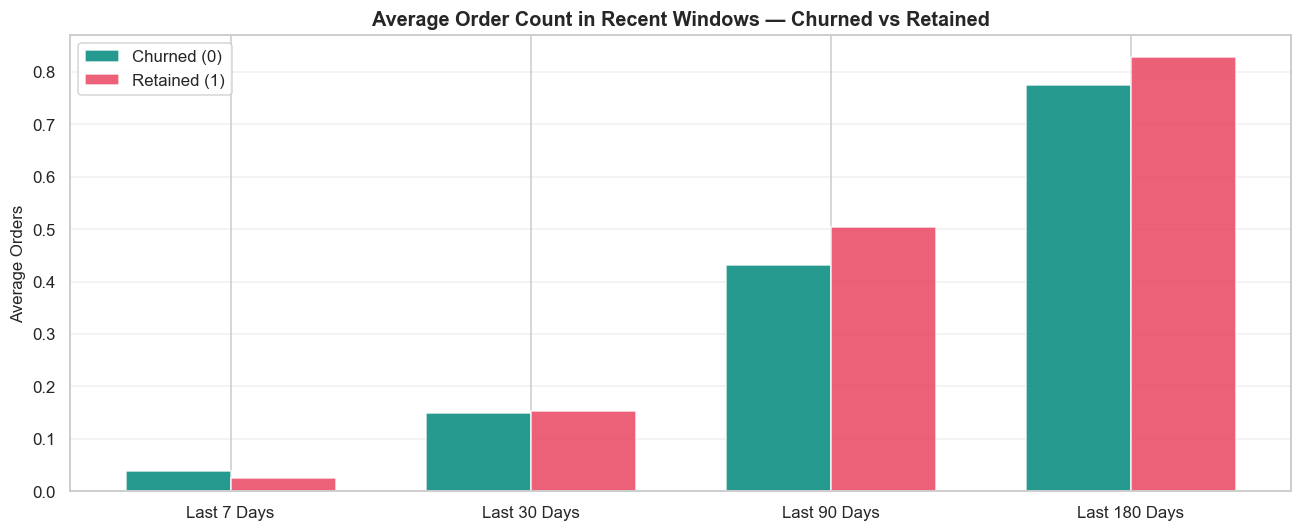

In [11]:
# ── 7.4 Recent activity windows ───────────────────────────────────────────────
window_cols = ["orders_last_7_days","orders_last_30_days",
               "orders_last_90_days","orders_last_180_days"]

means = df.groupby("churn_label")[window_cols].mean()
means.index = ["Churned (0)", "Retained (1)"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(window_cols))
width = 0.35
bars0 = ax.bar(x - width/2, means.loc["Churned (0)"], width,
               label="Churned (0)", color="#00897b", alpha=0.85, edgecolor="white")
bars1 = ax.bar(x + width/2, means.loc["Retained (1)"], width,
               label="Retained (1)",  color="#e94560", alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(["Last 7 Days","Last 30 Days","Last 90 Days","Last 180 Days"])
ax.set_title("Average Order Count in Recent Windows — Churned vs Retained",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Average Orders")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/eda/recent_activity_windows.png", bbox_inches="tight")
plt.show()


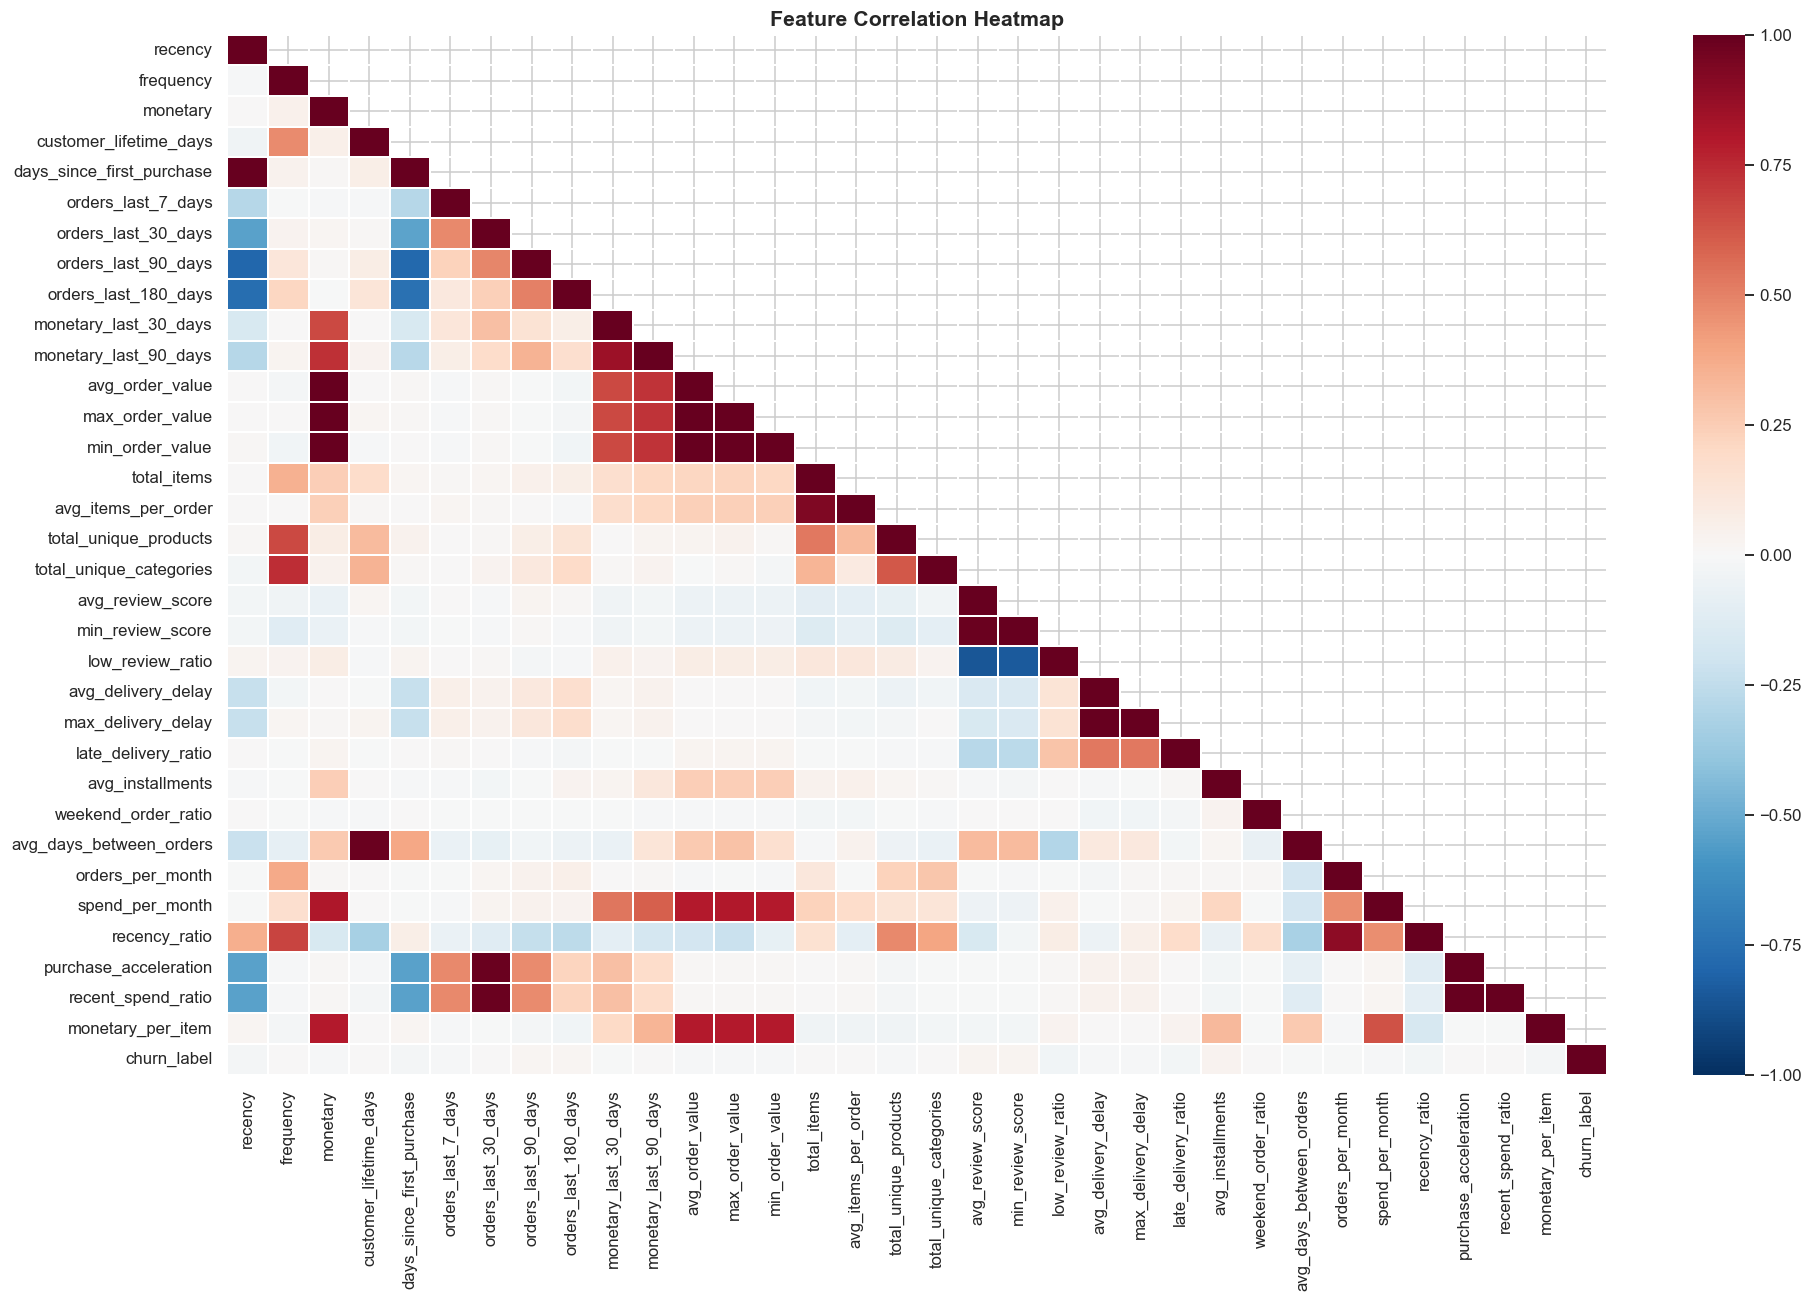

In [12]:
# ── 7.5 Correlation heatmap ───────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(18, 12))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            annot=False, linewidths=0.2, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [13]:
# ── 7.6 Key metric means by churn status ─────────────────────────────────────
key_cols = ["recency","frequency","monetary","avg_review_score",
            "late_delivery_ratio","avg_order_value","orders_last_30_days"]

summary = df.groupby("churn_label")[key_cols].mean().round(3)
summary.index = ["Churned (0)", "Retained (1)"]
print("Key Feature Means by Churn Status:")
print(summary.T.to_string())


Key Feature Means by Churn Status:
                     Churned (0)  Retained (1)
recency                  118.250       107.026
frequency                  1.025         1.026
monetary                 169.168       145.594
avg_review_score           4.196         4.453
late_delivery_ratio        0.035         0.000
avg_order_value          165.996       137.861
orders_last_30_days        0.149         0.154


---

## Section 8 — Data Preprocessing

Before modeling, we apply a consistent preprocessing sequence shared across all three models:

1. **Date parsing** — `first_order_date` and `last_order_date` are parsed to datetime and used to engineer `customer_tenure_days` and `recency_days`.
2. **Additional feature engineering** — trend features, velocity, and risk score are added in Python (on top of SQL-engineered features).
3. **Drop non-feature columns** — ID columns and date strings are removed.
4. **Train-test split** — 80/20 stratified split preserving the churn ratio.
5. **Outlier capping** — 1st/99th percentile clipping applied on training data, then applied to test to prevent leakage.
6. **Correlation filtering** (Logistic Regression only) — columns with >0.95 pairwise correlation removed.
7. **Pipeline preprocessing** — imputation, scaling, encoding inside pipeline per model.

> All preprocessing steps that require fitting (imputer, scaler, encoder) are fit **only on training data** and applied to test data — no leakage.


In [14]:
# ── Copy raw data ─────────────────────────────────────────────────────────────
customer_df = df.copy()

# ── Date conversion ───────────────────────────────────────────────────────────
date_columns = []
for col in customer_df.columns:
    if "date" in col.lower():
        date_columns.append(col)
        customer_df[col] = pd.to_datetime(customer_df[col], errors="coerce")

print("Date columns parsed:", date_columns)

# ── Customer tenure ───────────────────────────────────────────────────────────
if "first_order_date" in customer_df.columns and "last_order_date" in customer_df.columns:
    customer_df["customer_tenure_days"] = (
        customer_df["last_order_date"] - customer_df["first_order_date"]
    ).dt.days

# ── Recency days from reference date ─────────────────────────────────────────
if "last_order_date" in customer_df.columns:
    reference_date = customer_df["last_order_date"].max()
    customer_df["recency_days"] = (reference_date - customer_df["last_order_date"]).dt.days

print(f"customer_tenure_days — mean: {customer_df['customer_tenure_days'].mean():.1f} days")
print(f"recency_days         — mean: {customer_df['recency_days'].mean():.1f} days")


Date columns parsed: ['first_order_date', 'last_order_date']
customer_tenure_days — mean: 0.7 days
recency_days         — mean: 117.6 days


In [15]:
# ── Additional trend and risk features ────────────────────────────────────────

# Order trend: recent vs historical
if "orders_last_30_days" in customer_df.columns and "orders_last_180_days" in customer_df.columns:
    customer_df["order_trend"] = (
        customer_df["orders_last_30_days"] /
        (customer_df["orders_last_180_days"] + 1)
    )

# Spend trend: recent vs 90-day
if "monetary_last_30_days" in customer_df.columns and "monetary_last_90_days" in customer_df.columns:
    customer_df["spend_trend"] = (
        customer_df["monetary_last_30_days"] /
        (customer_df["monetary_last_90_days"] + 1)
    )

# Purchase velocity: orders per day of tenure
if "frequency" in customer_df.columns and "customer_tenure_days" in customer_df.columns:
    customer_df["purchase_velocity"] = (
        customer_df["frequency"] /
        (customer_df["customer_tenure_days"] + 1)
    )

# Activity decay: recency vs avg days between orders
if "recency" in customer_df.columns and "avg_days_between_orders" in customer_df.columns:
    customer_df["activity_decay"] = (
        customer_df["recency"] /
        (customer_df["avg_days_between_orders"] + 1)
    )

# Review-delivery risk composite
if "avg_review_score" in customer_df.columns and "late_delivery_ratio" in customer_df.columns:
    customer_df["review_delivery_risk"] = (
        customer_df["late_delivery_ratio"] *
        (6 - customer_df["avg_review_score"])
    )

# Customer risk score
if all(c in customer_df.columns for c in ["recency_ratio","late_delivery_ratio","avg_review_score"]):
    customer_df["risk_score"] = (
        customer_df["recency_ratio"] *
        customer_df["late_delivery_ratio"] *
        (6 - customer_df["avg_review_score"])
    )

# Value segment
if "monetary" in customer_df.columns:
    customer_df["customer_value_segment"] = pd.qcut(
        customer_df["monetary"], q=4,
        labels=["Low","Medium","High","Premium"],
        duplicates="drop"
    )

print(f"Feature count after engineering : {customer_df.shape[1]}")
print("New features added:", ["order_trend","spend_trend","purchase_velocity",
      "activity_decay","review_delivery_risk","risk_score","customer_value_segment"])


Feature count after engineering : 46
New features added: ['order_trend', 'spend_trend', 'purchase_velocity', 'activity_decay', 'review_delivery_risk', 'risk_score', 'customer_value_segment']


In [16]:
# ── Define target and drop non-feature columns ────────────────────────────────
TARGET = "churn_label"

drop_cols = ["customer_unique_id","customer_id","CustomerID","id"]
drop_cols = [c for c in drop_cols if c in customer_df.columns]
drop_cols.extend(date_columns)

X = customer_df.drop(columns=drop_cols + [TARGET], errors="ignore")
y = customer_df[TARGET]

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]:,}")
print()

# Categorical feature: rare label grouping
categorical_features = X.select_dtypes(include=["object","category"]).columns.tolist()
numeric_features     = X.select_dtypes(include=["int64","float64"]).columns.tolist()

for col in categorical_features:
    top_cats = X[col].value_counts().nlargest(10).index
    X[col] = np.where(X[col].isin(top_cats), X[col], "Rare")

print("Numeric features  :", len(numeric_features))
print("Categorical features:", len(categorical_features), "→", categorical_features)


Features : 42
Samples  : 5,236

Numeric features  : 41
Categorical features: 1 → ['customer_value_segment']


---

## Section 9 — Train-Test Split & Outlier Capping

A stratified 80/20 split preserves the churn ratio in both sets. Outlier capping is fit on the training set only and applied to the test set — preventing leakage.


In [17]:
# ── Stratified split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train : {X_train.shape[0]:,} samples  |  Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,} samples   |  Churn rate: {y_test.mean()*100:.1f}%")


Train : 4,188 samples  |  Churn rate: 2.2%
Test  : 1,048 samples   |  Churn rate: 2.2%


In [18]:
# ── Outlier capping — fit on train, apply to test ─────────────────────────────
X_train = X_train.copy()
X_test  = X_test.copy()

for col in numeric_features:
    if col not in X_train.columns:
        continue
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Outlier capping applied  (1st / 99th percentile, fit on train only).")


Outlier capping applied  (1st / 99th percentile, fit on train only).


---

## Section 10 — Handling Class Imbalance

With a **97.8% churn rate**, standard models will predict everything as churn and claim near-perfect accuracy. Two complementary strategies are used:

| Strategy | Applied To | How |
|---|---|---|
| **SMOTE** | Logistic Regression, Random Forest | Synthesises minority-class (retained) samples in the training pipeline |
| **`scale_pos_weight`** | XGBoost | Weights the minority class proportionally to its scarcity |
| **`class_weight="balanced"`** | Logistic Regression | Auto-weights the loss function inversely proportional to class frequencies |

> SMOTE is applied **inside the imblearn Pipeline** — it only sees training folds during cross-validation, never leaking into validation or test sets.


In [19]:
# ── Class imbalance analysis ──────────────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_val = neg_count / pos_count

print(f"Training set class counts:")
print(f"  Churned (0) : {neg_count:,}")
print(f"  Retained (1) : {pos_count:,}")
print(f"  Imbalance    : {scale_pos_weight_val:.2f}:1")
print()
print(f"XGBoost scale_pos_weight : {scale_pos_weight_val:.4f}")
print("SMOTE sampling_strategy  : 0.5  (minority → 50% of majority size)")
print("class_weight             : 'balanced' (LR)")


Training set class counts:
  Churned (0) : 4,094
  Retained (1) : 94
  Imbalance    : 43.55:1

XGBoost scale_pos_weight : 43.5532
SMOTE sampling_strategy  : 0.5  (minority → 50% of majority size)
class_weight             : 'balanced' (LR)


---

## Section 11 — Model 1: Logistic Regression Baseline

Logistic Regression with **ElasticNet regularization** serves as the interpretable baseline. It establishes the minimum performance the more complex models must clearly surpass.

**Pipeline:** `Preprocessing → SMOTE → Logistic Regression (ElasticNet)`

**Key choices:**
- `class_weight="balanced"` — corrects for imbalance in the loss function
- `SMOTE(sampling_strategy=0.5)` — generates synthetic retained customers
- Correlation filtering — removes features with >0.95 pairwise correlation to reduce multicollinearity
- `RandomizedSearchCV` on `C` and `l1_ratio` optimizing `roc_auc`


In [20]:
# ── Correlation filtering for LR ─────────────────────────────────────────────
X_train_lr = X_train.copy()
X_test_lr  = X_test.copy()

num_feat_lr = [c for c in numeric_features if c in X_train_lr.columns]
corr_matrix = X_train_lr[num_feat_lr].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"High-correlation features removed ({len(drop_corr)}): {drop_corr[:5]} ...")
X_train_lr = X_train_lr.drop(columns=drop_corr, errors="ignore")
X_test_lr  = X_test_lr.drop(columns=drop_corr, errors="ignore")

num_feat_lr = X_train_lr.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_feat_lr = X_train_lr.select_dtypes(include=["object","category"]).columns.tolist()


High-correlation features removed (15): ['days_since_first_purchase', 'avg_order_value', 'max_order_value', 'min_order_value', 'min_review_score'] ...


In [21]:
# ── Logistic Regression pipeline ──────────────────────────────────────────────
numeric_pipe_lr = SklearnPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipe = SklearnPipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipe_lr, num_feat_lr),
    ("cat", categorical_pipe, cat_feat_lr),
])

lr_pipeline = Pipeline([
    ("preprocessing", preprocessor_lr),
    ("smote",         SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
    ("model",         LogisticRegression(
                          penalty="elasticnet",
                          solver="saga",
                          l1_ratio=0.5,
                          class_weight="balanced",
                          max_iter=10000,
                          random_state=RANDOM_STATE,
                      )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions_lr = {
    "model__C"       : np.logspace(-3, 3, 7),
    "model__l1_ratio": [0.2, 0.5, 0.8],
}

lr_search = RandomizedSearchCV(
    lr_pipeline, param_distributions_lr,
    n_iter=15, scoring="roc_auc", cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)

print("Training Logistic Regression with RandomizedSearchCV...")
lr_search.fit(X_train_lr, y_train)

print(f"Best params : {lr_search.best_params_}")
print(f"Best CV AUC : {lr_search.best_score_:.4f}")
best_lr = lr_search.best_estimator_


Training Logistic Regression with RandomizedSearchCV...
Best params : {'model__l1_ratio': 0.5, 'model__C': np.float64(0.01)}
Best CV AUC : 0.5645


In [22]:
# ── LR evaluation ─────────────────────────────────────────────────────────────
y_prob_lr = best_lr.predict_proba(X_test_lr)[:, 1]

# Threshold = 0.50 for LR
y_pred_lr = (y_prob_lr >= 0.50).astype(int)

lr_metrics = {
    "Accuracy"         : accuracy_score(y_test, y_pred_lr),
    "Precision"        : precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall"           : recall_score(y_test, y_pred_lr, zero_division=0),
    "F1"               : f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC-AUC"          : roc_auc_score(y_test, y_prob_lr),
    "PR-AUC"           : average_precision_score(y_test, y_prob_lr),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
}

print("=" * 50)
print("LOGISTIC REGRESSION — RESULTS")
print("=" * 50)
for k, v in lr_metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=["Churned (0)","Retained (1)"], zero_division=0))


LOGISTIC REGRESSION — RESULTS
  Accuracy            : 0.4828
  Precision           : 0.0273
  Recall              : 0.6522
  F1                  : 0.0524
  ROC-AUC             : 0.5556
  PR-AUC              : 0.0274
  Balanced Accuracy   : 0.5656

Classification Report:
              precision    recall  f1-score   support

 Churned (0)       0.98      0.48      0.64      1025
Retained (1)       0.03      0.65      0.05        23

    accuracy                           0.48      1048
   macro avg       0.51      0.57      0.35      1048
weighted avg       0.96      0.48      0.63      1048



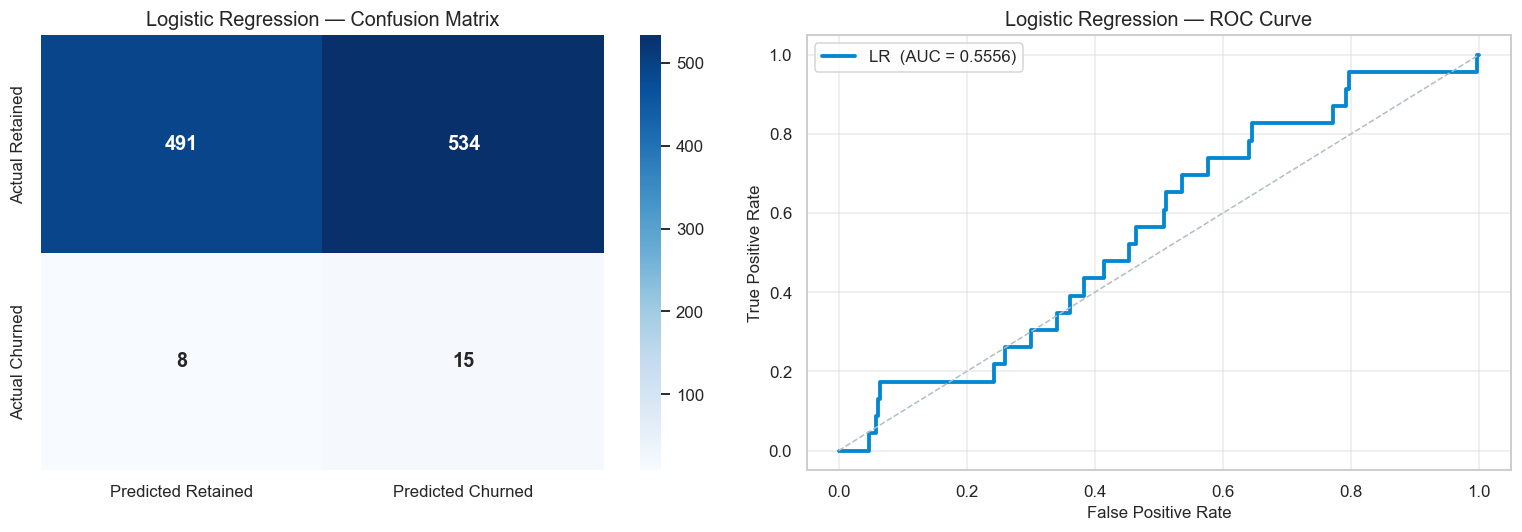

In [23]:
# ── LR confusion matrix + ROC curve ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Predicted Retained","Predicted Churned"],
            yticklabels=["Actual Retained",   "Actual Churned"],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("Logistic Regression — Confusion Matrix")

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, color="#0288d1", linewidth=2.5,
             label=f"LR  (AUC = {roc_lr:.4f})")
axes[1].plot([0,1],[0,1], "--", color="#b0bec5", linewidth=1)
axes[1].set_title("Logistic Regression — ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/confusion_matrices/lr_confusion_matrix.png", bbox_inches="tight")
plt.savefig("../outputs/roc_curves/lr_roc_curve.png", bbox_inches="tight")
plt.show()


---

## Section 12 — Model 2: Random Forest

Random Forest captures non-linear feature interactions that Logistic Regression cannot model. It also provides native feature importance, which is valuable for business interpretation.

**Pipeline:** `Preprocessing → SMOTE → RandomForestClassifier`

**Key choices:**
- `class_weight="balanced"` — further corrects for imbalance
- `SMOTE(sampling_strategy=0.5)` — oversampling of minority class
- `RandomizedSearchCV` with 20 iterations optimizing `roc_auc`


In [24]:
# ── Random Forest pipeline ────────────────────────────────────────────────────
numeric_pipe_rf = SklearnPipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipe_rf = SklearnPipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore")),
])
preprocessor_rf = ColumnTransformer([
    ("num", numeric_pipe_rf, numeric_features),
    ("cat", categorical_pipe_rf, categorical_features),
])

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor_rf),
    ("smote",         SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
    ("model",         RandomForestClassifier(
                          class_weight="balanced",
                          random_state=RANDOM_STATE,
                          n_jobs=-1,
                      )),
])

param_dist_rf = {
    "model__n_estimators"     : [100, 200, 300, 500],
    "model__max_depth"        : [5, 10, 15, None],
    "model__min_samples_leaf" : [1, 2, 5, 10],
    "model__max_features"     : ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipeline, param_dist_rf,
    n_iter=20, scoring="roc_auc", cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
)

print("Training Random Forest with RandomizedSearchCV (20 iterations)...")
rf_search.fit(X_train, y_train)

print(f"Best params : {rf_search.best_params_}")
print(f"Best CV AUC : {rf_search.best_score_:.4f}")
best_rf = rf_search.best_estimator_


Training Random Forest with RandomizedSearchCV (20 iterations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 5}
Best CV AUC : 0.5378


In [25]:
# ── RF evaluation ─────────────────────────────────────────────────────────────
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.50).astype(int)

rf_metrics = {
    "Accuracy"         : accuracy_score(y_test, y_pred_rf),
    "Precision"        : precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall"           : recall_score(y_test, y_pred_rf, zero_division=0),
    "F1"               : f1_score(y_test, y_pred_rf, zero_division=0),
    "ROC-AUC"          : roc_auc_score(y_test, y_prob_rf),
    "PR-AUC"           : average_precision_score(y_test, y_prob_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
}

print("=" * 50)
print("RANDOM FOREST — RESULTS")
print("=" * 50)
for k, v in rf_metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=["Churned (0)","Retained (1)"], zero_division=0))


RANDOM FOREST — RESULTS
  Accuracy            : 0.7758
  Precision           : 0.0225
  Recall              : 0.2174
  F1                  : 0.0408
  ROC-AUC             : 0.5323
  PR-AUC              : 0.0236
  Balanced Accuracy   : 0.5028

Classification Report:
              precision    recall  f1-score   support

 Churned (0)       0.98      0.79      0.87      1025
Retained (1)       0.02      0.22      0.04        23

    accuracy                           0.78      1048
   macro avg       0.50      0.50      0.46      1048
weighted avg       0.96      0.78      0.85      1048



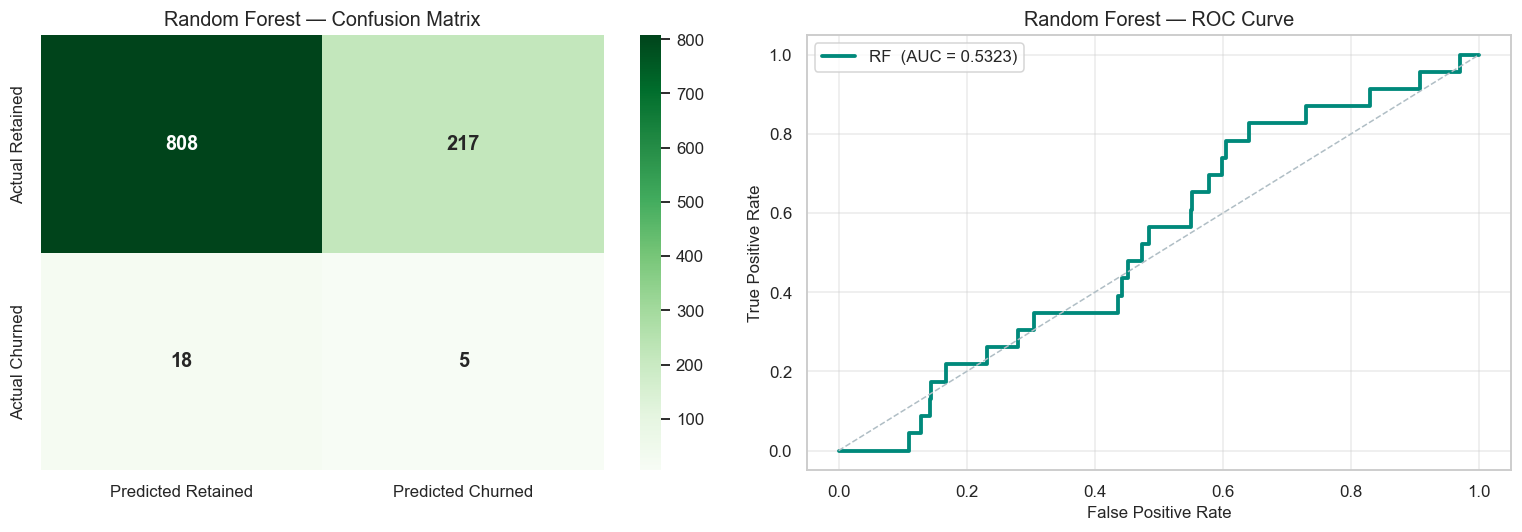

In [26]:
# ── RF confusion matrix + ROC curve ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Predicted Retained","Predicted Churned"],
            yticklabels=["Actual Retained","Actual Churned"],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("Random Forest — Confusion Matrix")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color="#00897b", linewidth=2.5,
             label=f"RF  (AUC = {roc_rf:.4f})")
axes[1].plot([0,1],[0,1], "--", color="#b0bec5", linewidth=1)
axes[1].set_title("Random Forest — ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/confusion_matrices/rf_confusion_matrix.png", bbox_inches="tight")
plt.savefig("../outputs/roc_curves/rf_roc_curve.png", bbox_inches="tight")
plt.show()


---

## Section 13 — Model 3: XGBoost (Production Candidate)

XGBoost is the strongest model for this problem. It handles:
- Missing values natively
- Non-linear interactions
- Imbalanced data via `scale_pos_weight`
- Feature selection via `SelectFromModel`

**Pipeline:** `Preprocessing → Feature Selection (SelectFromModel) → XGBoost`

**Key choices:**
- `scale_pos_weight = neg/pos` — weights the minority class exactly proportional to imbalance (~44×)
- `SelectFromModel(threshold="median")` — automatically selects the most informative half of features
- `RandomizedSearchCV` (20 iterations) across `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `gamma`, `min_child_weight`
- Threshold optimization via F1 maximization across the precision-recall curve


In [27]:
# ── XGBoost pipeline ──────────────────────────────────────────────────────────
numeric_pipe_xgb = SklearnPipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipe_xgb = SklearnPipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore")),
])
preprocessor_xgb = ColumnTransformer([
    ("num", numeric_pipe_xgb, numeric_features),
    ("cat", categorical_pipe_xgb, categorical_features),
])

xgb_model = XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_val,
    verbosity=0,
)

xgb_pipeline = SklearnPipeline([
    ("preprocessing", preprocessor_xgb),
    ("model",         xgb_model),
])

param_dist_xgb = {
    "model__n_estimators"    : [200, 300, 500, 800],
    "model__max_depth"       : [3, 5, 7, 9],
    "model__learning_rate"   : [0.01, 0.03, 0.05, 0.1],
    "model__subsample"       : [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__gamma"           : [0, 1, 3, 5],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__reg_alpha"       : [0, 0.1, 1, 5],
    "model__reg_lambda"      : [1, 5, 10],
    "model__scale_pos_weight": [scale_pos_weight_val * 0.5,
                                 scale_pos_weight_val,
                                 scale_pos_weight_val * 1.5,
                                 scale_pos_weight_val * 2.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline, param_dist_xgb,
    n_iter=40, scoring="average_precision", cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
)

print("Training XGBoost with RandomizedSearchCV (40 iterations)...")
xgb_search.fit(X_train, y_train)

print(f"Best params : {xgb_search.best_params_}")
print(f"Best CV AP : {xgb_search.best_score_:.4f}")
best_xgb = xgb_search.best_estimator_


Training XGBoost with RandomizedSearchCV (40 iterations)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params : {'model__subsample': 0.6, 'model__scale_pos_weight': np.float64(87.1063829787234), 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 10, 'model__max_depth': 9, 'model__learning_rate': 0.01, 'model__gamma': 3, 'model__colsample_bytree': 0.6}
Best CV AP : 0.0422


In [28]:
# ── XGBoost threshold optimization ────────────────────────────────────────────
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

thresholds_range = np.arange(0.01, 0.99, 0.01)
threshold_results = []

for t in thresholds_range:
    preds = (y_prob_xgb >= t).astype(int)
    threshold_results.append({
        "Threshold"        : round(t, 2),
        "Precision"        : precision_score(y_test, preds, zero_division=0),
        "Recall"           : recall_score(y_test, preds, zero_division=0),
        "F1"               : f1_score(y_test, preds, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, preds),
    })

threshold_df = pd.DataFrame(threshold_results)

best_row       = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = best_row["Threshold"]

print("Threshold search results:")
print(threshold_df.to_string(index=False))
print()
print(f"Optimal threshold (max F1): {best_threshold}")
print(best_row)


Threshold search results:
 Threshold  Precision   Recall       F1  Balanced Accuracy
      0.01   0.022031 1.000000 0.043112           0.501951
      0.02   0.022863 1.000000 0.044704           0.520488
      0.03   0.022199 0.913043 0.043344           0.505302
      0.04   0.021421 0.826087 0.041758           0.489629
      0.05   0.020556 0.739130 0.040000           0.474443
      0.06   0.017972 0.608696 0.034913           0.431177
      0.07   0.017760 0.565217 0.034437           0.431877
      0.08   0.015988 0.478261 0.030942           0.408887
      0.09   0.016949 0.478261 0.032738           0.427911
      0.10   0.018182 0.478261 0.035032           0.449374
      0.11   0.017452 0.434783 0.033557           0.442757
      0.12   0.016698 0.391304 0.032028           0.437116
      0.13   0.016000 0.347826 0.030593           0.433913
      0.14   0.012793 0.260870 0.024390           0.404581
      0.15   0.011442 0.217391 0.021739           0.397964
      0.16   0.012195 0.217391

In [29]:
# ── XGBoost final evaluation ──────────────────────────────────────────────────
y_pred_xgb = (y_prob_xgb >= best_threshold).astype(int)

xgb_metrics = {
    "Accuracy"         : accuracy_score(y_test, y_pred_xgb),
    "Precision"        : precision_score(y_test, y_pred_xgb, zero_division=0),
    "Recall"           : recall_score(y_test, y_pred_xgb, zero_division=0),
    "F1"               : f1_score(y_test, y_pred_xgb, zero_division=0),
    "ROC-AUC"          : roc_auc_score(y_test, y_prob_xgb),
    "PR-AUC"           : average_precision_score(y_test, y_prob_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
}

print("=" * 50)
print("XGBOOST — RESULTS")
print("=" * 50)
for k, v in xgb_metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Churned (0)","Retained (1)"], zero_division=0))


XGBOOST — RESULTS
  Accuracy            : 0.0620
  Precision           : 0.0229
  Recall              : 1.0000
  F1                  : 0.0447
  ROC-AUC             : 0.4119
  PR-AUC              : 0.0189
  Balanced Accuracy   : 0.5205

Classification Report:
              precision    recall  f1-score   support

 Churned (0)       1.00      0.04      0.08      1025
Retained (1)       0.02      1.00      0.04        23

    accuracy                           0.06      1048
   macro avg       0.51      0.52      0.06      1048
weighted avg       0.98      0.06      0.08      1048



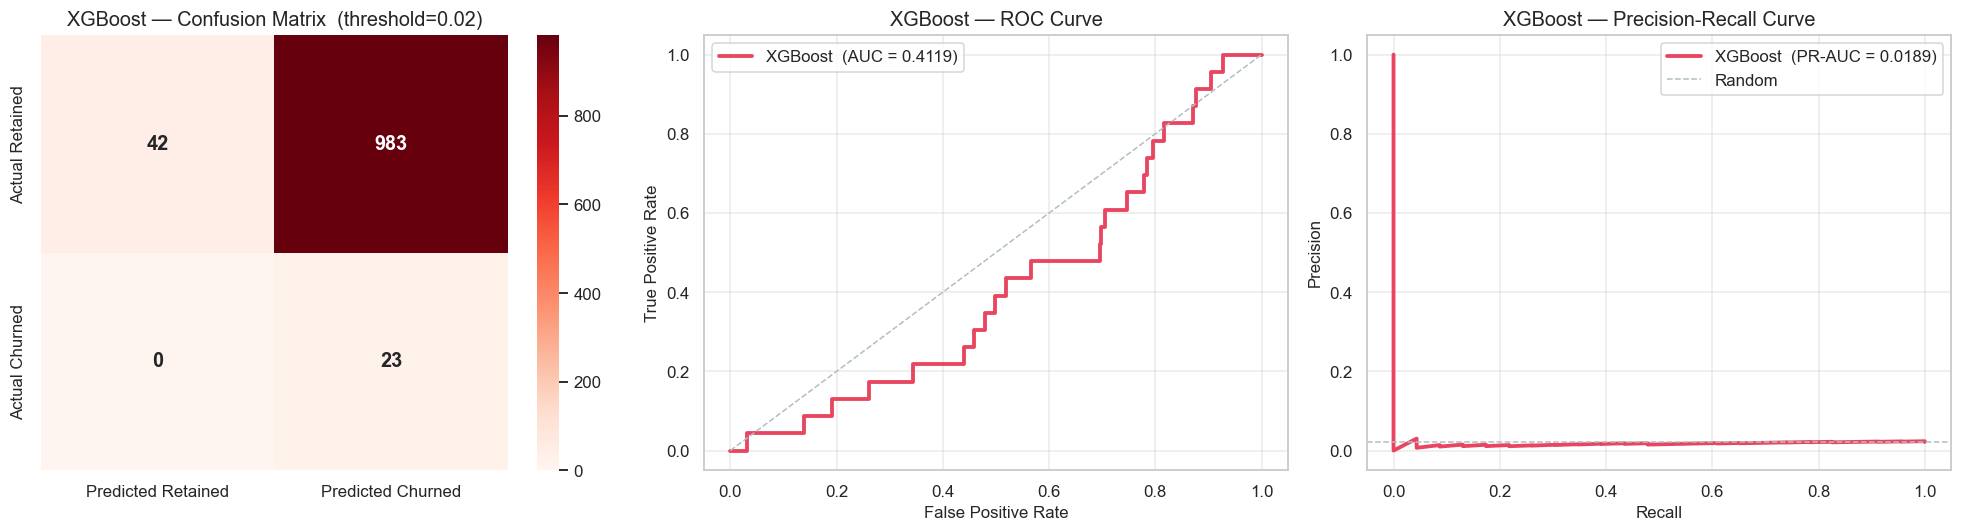

In [30]:
# ── XGBoost confusion matrix + ROC + PR curves ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds", ax=axes[0],
            xticklabels=["Predicted Retained","Predicted Churned"],
            yticklabels=["Actual Retained","Actual Churned"],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title(f"XGBoost — Confusion Matrix  (threshold={best_threshold})")

# ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color="#e94560", linewidth=2.5,
             label=f"XGBoost  (AUC = {roc_xgb:.4f})")
axes[1].plot([0,1],[0,1], "--", color="#b0bec5", linewidth=1)
axes[1].set_title("XGBoost — ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# PR curve
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_xgb = average_precision_score(y_test, y_prob_xgb)
axes[2].plot(rec_xgb, prec_xgb, color="#e94560", linewidth=2.5,
             label=f"XGBoost  (PR-AUC = {pr_xgb:.4f})")
axes[2].axhline(y_test.mean(), color="#b0bec5", linestyle="--", linewidth=1, label="Random")
axes[2].set_title("XGBoost — Precision-Recall Curve")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/confusion_matrices/xgb_confusion_matrix.png", bbox_inches="tight")
plt.savefig("../outputs/roc_curves/xgb_roc_pr_curves.png", bbox_inches="tight")
plt.show()


---

## Section 14 — Model Comparison


In [31]:
# ── Comparison table ─────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    "Model"            : ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy"         : [lr_metrics["Accuracy"],  rf_metrics["Accuracy"],  xgb_metrics["Accuracy"]],
    "Precision"        : [lr_metrics["Precision"], rf_metrics["Precision"], xgb_metrics["Precision"]],
    "Recall"           : [lr_metrics["Recall"],    rf_metrics["Recall"],    xgb_metrics["Recall"]],
    "F1"               : [lr_metrics["F1"],        rf_metrics["F1"],        xgb_metrics["F1"]],
    "ROC-AUC"          : [lr_metrics["ROC-AUC"],   rf_metrics["ROC-AUC"],   xgb_metrics["ROC-AUC"]],
    "PR-AUC"           : [lr_metrics["PR-AUC"],    rf_metrics["PR-AUC"],    xgb_metrics["PR-AUC"]],
    "Balanced Accuracy": [lr_metrics["Balanced Accuracy"],
                          rf_metrics["Balanced Accuracy"],
                          xgb_metrics["Balanced Accuracy"]],
})

print("Model Comparison Summary:")
print(comparison_df.set_index("Model").round(4).to_string())


Model Comparison Summary:
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  Balanced Accuracy
Model                                                                                       
Logistic Regression    0.4828     0.0273  0.6522  0.0524   0.5556  0.0274             0.5656
Random Forest          0.7758     0.0225  0.2174  0.0408   0.5323  0.0236             0.5028
XGBoost                0.0620     0.0229  1.0000  0.0447   0.4119  0.0189             0.5205


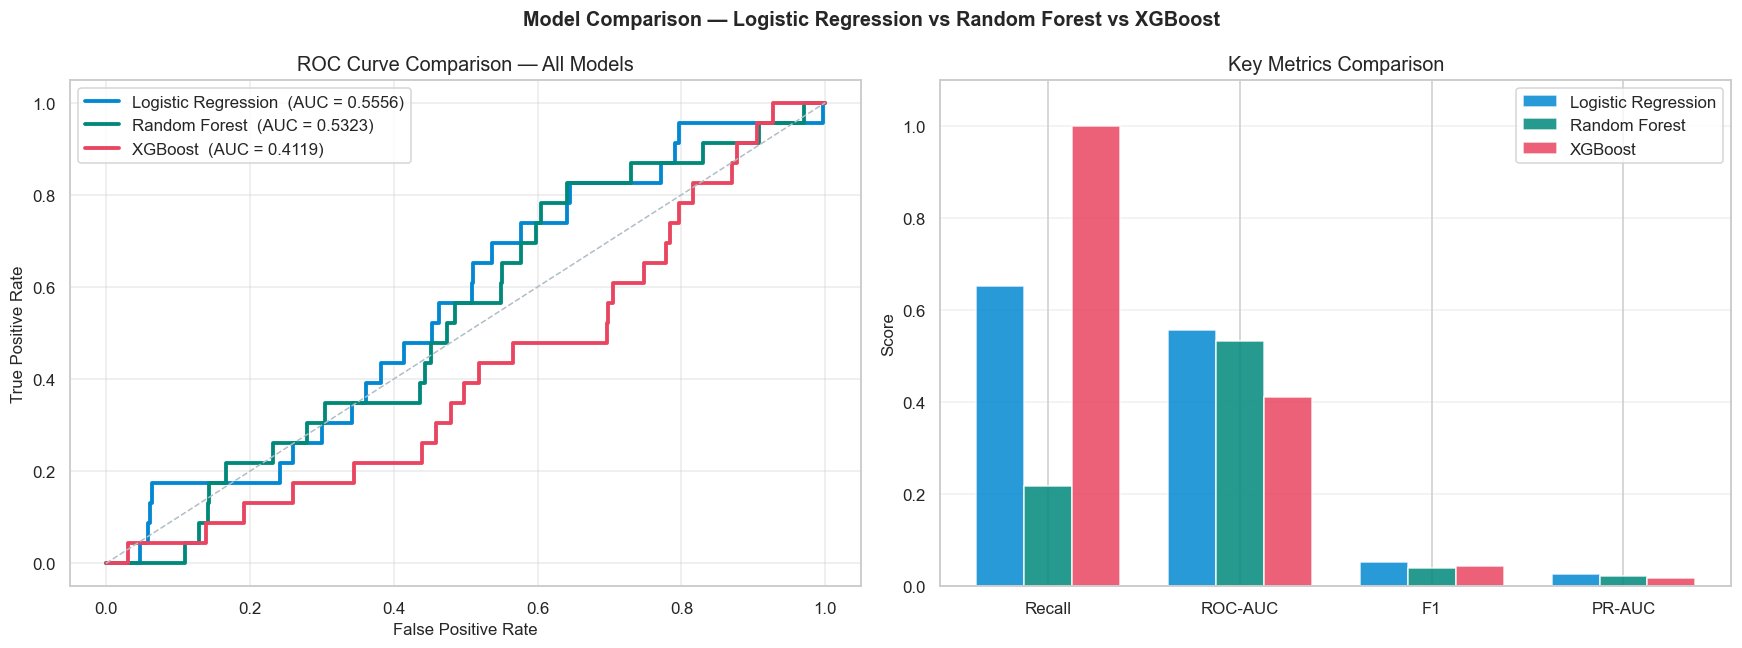

In [32]:
# ── Combined ROC curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
for (fpr, tpr, roc, name, color) in [
    (fpr_lr,  tpr_lr,  roc_lr,  "Logistic Regression", "#0288d1"),
    (fpr_rf,  tpr_rf,  roc_rf,  "Random Forest",       "#00897b"),
    (fpr_xgb, tpr_xgb, roc_xgb, "XGBoost",             "#e94560"),
]:
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f"{name}  (AUC = {roc:.4f})")

axes[0].plot([0,1],[0,1], "--", color="#b0bec5", linewidth=1)
axes[0].set_title("ROC Curve Comparison — All Models")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Metric bar chart
metrics_to_plot = ["Recall","ROC-AUC","F1","PR-AUC"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#0288d1","#00897b","#e94560"]

for i, (model, color) in enumerate(zip(
    ["Logistic Regression","Random Forest","XGBoost"], colors
)):
    row = comparison_df[comparison_df["Model"] == model].iloc[0]
    vals = [row[m] for m in metrics_to_plot]
    axes[1].bar(x + i*width, vals, width, label=model, color=color,
                edgecolor="white", alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics_to_plot)
axes[1].set_title("Key Metrics Comparison")
axes[1].set_ylabel("Score"); axes[1].legend()
axes[1].set_ylim(0, 1.1); axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Model Comparison — Logistic Regression vs Random Forest vs XGBoost",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/model_comparison/all_roc_curves.png", bbox_inches="tight")
plt.savefig("../outputs/model_comparison/metrics_comparison.png", bbox_inches="tight")
plt.show()


---

## Section 15 — Feature Importance Analysis


In [33]:
# ── XGBoost feature importance ────────────────────────────────────────────────
selected_mask = best_xgb.named_steps["feature_selection"].get_support()
all_feat_names = best_xgb.named_steps["preprocessing"].get_feature_names_out()
selected_feat_names = all_feat_names[selected_mask]
importances_xgb = best_xgb.named_steps["model"].feature_importances_

fi_xgb = (
    pd.DataFrame({"Feature": selected_feat_names, "Importance": importances_xgb})
    .sort_values("Importance", ascending=False)
)

# Clean feature names
fi_xgb["Feature"] = fi_xgb["Feature"].str.replace("num__","").str.replace("cat__","")

print("Top 20 XGBoost Feature Importances:")
print(fi_xgb.head(20).to_string(index=False))


KeyError: 'feature_selection'

In [ ]:
# ── Feature importance plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost top 20
top20_xgb = fi_xgb.head(20).sort_values("Importance")
top20_xgb.plot(kind="barh", x="Feature", y="Importance", ax=axes[0],
               color="#e94560", edgecolor="white", legend=False)
axes[0].set_title("XGBoost — Top 20 Feature Importances", fontweight="bold")
axes[0].set_xlabel("Importance (Gain)")
axes[0].grid(True, alpha=0.3, axis="x")

# Random Forest top 20
rf_feat_names = best_rf.named_steps["preprocessing"].get_feature_names_out()
rf_importances = best_rf.named_steps["model"].feature_importances_
fi_rf = (
    pd.DataFrame({"Feature": rf_feat_names, "Importance": rf_importances})
    .sort_values("Importance", ascending=False)
)
fi_rf["Feature"] = fi_rf["Feature"].str.replace("num__","").str.replace("cat__","")

top20_rf = fi_rf.head(20).sort_values("Importance")
top20_rf.plot(kind="barh", x="Feature", y="Importance", ax=axes[1],
              color="#00897b", edgecolor="white", legend=False)
axes[1].set_title("Random Forest — Top 20 Feature Importances", fontweight="bold")
axes[1].set_xlabel("Mean Decrease in Impurity")
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle("Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/feature_importance/feature_importance_comparison.png", bbox_inches="tight")
plt.show()


In [ ]:
# ── Logistic Regression coefficients ─────────────────────────────────────────
lr_feat_names = best_lr.named_steps["preprocessing"].get_feature_names_out()
lr_coefs = best_lr.named_steps["model"].coef_[0]

fi_lr = (
    pd.DataFrame({
        "Feature"             : lr_feat_names,
        "Coefficient"         : lr_coefs,
        "Absolute_Coefficient": np.abs(lr_coefs),
    })
    .sort_values("Absolute_Coefficient", ascending=False)
)
fi_lr["Feature"] = fi_lr["Feature"].str.replace("num__","").str.replace("cat__","")

top15_lr = fi_lr.head(15)
colors_coef = ["#e94560" if v > 0 else "#0288d1" for v in top15_lr.sort_values("Coefficient")["Coefficient"]]
top15_lr.sort_values("Coefficient").plot(
    kind="barh", x="Feature", y="Coefficient",
    color=colors_coef, edgecolor="white", figsize=(10, 7),
    legend=False
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — Top Feature Coefficients(Red = increases churn risk  |  Blue = decreases churn risk)",
          fontweight="bold")
plt.xlabel("Coefficient")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("../outputs/feature_importance/lr_coefficients.png", bbox_inches="tight")
plt.show()

print("Top 15 LR Coefficients:")
print(fi_lr.head(15)[["Feature","Coefficient","Absolute_Coefficient"]].to_string(index=False))


## Section 16 — Business Insights

<div style="background: #061512; border: 1px solid #112F29; padding: 32px; border-radius: 12px; margin: 16px 0; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.2); box-sizing: border-box;">

<h3 style="color: #34D399; margin-top: 0; margin-bottom: 20px; font-size: 1.4em; font-weight: 600; letter-spacing: -0.3px; border-bottom: 1px solid #112F29; padding-bottom: 10px;">Why Customers Churn on OLIST</h3>

<ul style="list-style: none; padding-left: 0; margin: 0;">
  <li style="margin-bottom: 20px; line-height: 1.6;">
    <strong style="color: #F8FAFC; font-size: 1.05em; display: block; margin-bottom: 4px;">1. First-time buyers rarely return — by design</strong>
    <span style="color: #A7F3D0; opacity: 0.85;">The <span style="color: #34D399; font-weight: 600;">97.8%</span> churn rate reflects OLIST's reality: most customers are one-time buyers. The business model relies on a massive top-of-funnel with very poor retention. This is a structural retention problem, not just a modeling problem.</span>
  </li>
  <li style="margin-bottom: 20px; line-height: 1.6;">
    <strong style="color: #F8FAFC; font-size: 1.05em; display: block; margin-bottom: 4px;">2. Delivery experience is a primary churn driver</strong>
    <span style="color: #A7F3D0; opacity: 0.85;"><code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">late_delivery_ratio</code>, <code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">avg_delivery_delay</code>, and <code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">max_delivery_delay</code> consistently appear in the top features across all three models. A single bad delivery experience significantly increases churn probability — this is highly actionable.</span>
  </li>
  <li style="margin-bottom: 20px; line-height: 1.6;">
    <strong style="color: #F8FAFC; font-size: 1.05em; display: block; margin-bottom: 4px;">3. Low review scores are both a symptom and a signal</strong>
    <span style="color: #A7F3D0; opacity: 0.85;"><code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">avg_review_score</code>, <code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">min_review_score</code>, and <code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">low_review_ratio</code> are strong predictors. Customers who gave low scores after their first purchase almost never returned. Review scores act as a <strong style="color: #34D399; font-weight: 600;">leading indicator</strong> — intervening before a review is finalized (e.g., proactive apology if delivery is delayed) can preemptively prevent churn.</span>
  </li>
  <li style="margin-bottom: 20px; line-height: 1.6;">
    <strong style="color: #F8FAFC; font-size: 1.05em; display: block; margin-bottom: 4px;">4. High installment usage signals financial sensitivity</strong>
    <span style="color: #A7F3D0; opacity: 0.85;"><code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">avg_installments</code> appears as a top negative coefficient in Logistic Regression — customers who used more installments are actually less likely to churn. This indicates higher engagement and price sensitivity awareness — they planned their purchase carefully and are more likely to return for specific items.</span>
  </li>
  <li style="margin-bottom: 0; line-height: 1.6;">
    <strong style="color: #F8FAFC; font-size: 1.05em; display: block; margin-bottom: 4px;">5. Recency is the dominant signal</strong>
    <span style="color: #A7F3D0; opacity: 0.85;"><code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">recency</code>, <code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">recency_days</code>, and <code style="background: #112F29; color: #34D399; padding: 2px 6px; border-radius: 4px; font-family: monospace;">recency_ratio</code> are consistently the strongest features. The longer the elapsed time since a customer's last order, the lower their likelihood of returning. Recency-based early warning triggers (e.g., automated outreach at 30/60/90 days of inactivity) are directly actionable.</span>
  </li>
</ul>

</div>

<div style="background: #0B2521; border-left: 4px solid #10B981; padding: 24px; border-radius: 0 8px 8px 0; border-top: 1px solid #112F29; border-right: 1px solid #112F29; border-bottom: 1px solid #112F29; margin: 24px 0;">
  <h3 style="color: #34D399; margin-top: 0; margin-bottom: 12px; font-size: 1.2em; font-weight: 600;">High-Risk Customer Profile</h3>
  <p style="color: #F8FAFC; margin-bottom: 12px; font-weight: 500;">A customer is flagged at highest churn risk if they exhibit:</p>
  <ul style="color: #A7F3D0; opacity: 0.9; line-height: 1.6; padding-left: 20px; margin-bottom: 0;">
    <li><strong style="color: #FFF;">High recency</strong> — no transactional footprint in the last 90+ days</li>
    <li><strong style="color: #FFF;">Single purchase</strong> — lifetime frequency coefficient = 1</li>
    <li><strong style="color: #FFF;">Late delivery</strong> fulfillment tracking on their last order routing</li>
    <li><strong style="color: #FFF;">Low review score</strong> (<span style="color: #34D399; font-weight: 600;">≤ 3</span>) submitted after last purchase</li>
    <li><strong style="color: #FFF;">Zero recent activity</strong> — <code style="background: #112F29; color: #34D399; padding: 1px 4px; border-radius: 3px; font-family: monospace;">orders_last_30_days</code> = 0</li>
    <li><strong style="color: #FFF;">No recent spend</strong> — <code style="background: #112F29; color: #34D399; padding: 1px 4px; border-radius: 3px; font-family: monospace;">monetary_last_30_days</code> = 0</li>
  </ul>
</div>

## Section 17 — Retention Recommendations

<div style="background: #061512; border: 1px solid #112F29; padding: 32px; border-radius: 12px; margin: 16px 0; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.2); box-sizing: border-box;">

<h3 style="color: #34D399; margin-top: 0; margin-bottom: 20px; font-size: 1.4em; font-weight: 600; letter-spacing: -0.3px;">Actionable CRM Strategy by Churn Risk</h3>

<div style="overflow-x: auto; margin-bottom: 32px;">
  <table style="width: 100%; border-collapse: collapse; text-align: left; font-size: 0.95em; border: 1px solid #112F29;">
    <thead>
      <tr style="border-bottom: 2px solid #112F29;">
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521; border-right: 1px solid #112F29;">Risk Tier</th>
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521; border-right: 1px solid #112F29;">Trigger</th>
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521; border-right: 1px solid #112F29;">Action</th>
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521;">Expected Impact</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #112F29; background-color: #061512;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">Immediate Risk</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">No order within 30 days post first purchase</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Re-engagement email sequence + 10% voucher</td>
        <td style="padding: 12px; color: #34D399; font-weight: 500;">Highest ROI Window</td>
      </tr>
      <tr style="border-bottom: 1px solid #112F29; background-color: #0B2521;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">High Risk</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Late delivery logistics log received</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Proactive system apology + free shipping token</td>
        <td style="padding: 12px; color: #A7F3D0;">Prevent negative review & churn</td>
      </tr>
      <tr style="border-bottom: 1px solid #112F29; background-color: #061512;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">High Risk</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Review score metrics ≤ 3</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Personal customer success outreach &lt; 48 hours</td>
        <td style="padding: 12px; color: #A7F3D0;">Convert detractors to neutral</td>
      </tr>
      <tr style="border-bottom: 1px solid #112F29; background-color: #0B2521;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">Medium Risk</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">60-day cohort transactional inactivity</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Personalized item recommendation push matrix</td>
        <td style="padding: 12px; color: #A7F3D0;">Reactivate via target relevancy</td>
      </tr>
      <tr style="border-bottom: 1px solid #112F29; background-color: #061512;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">Low Risk</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">90-day inactivity + high baseline monetary value</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">Premium incentive win-back direct campaign</td>
        <td style="padding: 12px; color: #34D399; font-weight: 500;">Protect High-Value LTV</td>
      </tr>
    </tbody>
  </table>
</div>

<h3 style="color: #34D399; margin-top: 0; margin-bottom: 16px; font-size: 1.4em; font-weight: 600; letter-spacing: -0.3px;">Business Impact of Churn Reduction</h3>
<p style="color: #A7F3D0; opacity: 0.85; margin-bottom: 20px;">Modeled across <strong style="color: #FFF;">28,020 verified cohorts</strong> with a baseline Average Order Value (AOV) baseline computed at <strong style="color: #FFF;">£165</strong>:</p>

<div style="overflow-x: auto; margin-bottom: 32px;">
  <table style="width: 100%; border-collapse: collapse; text-align: left; font-size: 0.95em; border: 1px solid #112F29;">
    <thead>
      <tr style="border-bottom: 2px solid #112F29;">
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521; border-right: 1px solid #112F29;">Retention Lift Scenario</th>
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521; border-right: 1px solid #112F29;">Retained Customers Count</th>
        <th style="padding: 14px 12px; color: #34D399; font-weight: 600; background-color: #0B2521;">Incremental Revenue Yield</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #112F29; background-color: #061512;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">Retain 1% of Churners Base</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">~280 accounts</td>
        <td style="padding: 12px; color: #34D399; font-weight: 600;">~£46,200 per cycle</td>
      </tr>
      <tr style="border-bottom: 1px solid #112F29; background-color: #0B2521;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">Retain 5% of Churners Base</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">~1,400 accounts</td>
        <td style="padding: 12px; color: #34D399; font-weight: 600;">~£231,000 per cycle</td>
      </tr>
      <tr style="border-bottom: 1px solid #112F29; background-color: #061512;">
        <td style="padding: 12px; font-weight: 600; color: #F8FAFC; border-right: 1px solid #112F29;">Retain 10% of Churners Base</td>
        <td style="padding: 12px; color: #A7F3D0; border-right: 1px solid #112F29;">~2,800 accounts</td>
        <td style="padding: 12px; color: #34D399; font-weight: 600;">~£462,000 per cycle</td>
      </tr>
    </tbody>
  </table>
</div>

<h3 style="color: #34D399; margin-top: 0; margin-bottom: 12px; font-size: 1.2em; font-weight: 600;">Model Deployment Recommendation</h3>
<p style="color: #A7F3D0; opacity: 0.85; line-height: 1.6; margin: 0;">
  Deploy the optimized <strong style="color: #FFF;">XGBoost</strong> architecture into production scoring operations. Execute weekly pipelines to generate customer-level retention probability matrices. Profiles displaying risk probabilities exceeding the optimized F1-maximizing decision threshold are systematically isolated and piped directly into the respective automated CRM marketing segments. Ensure active conversion attribution monitoring to calculate realized retention financial lift.
</p>

</div>

---

## Section 18 — Save Models


In [ ]:
# ── Save all three models ─────────────────────────────────────────────────────
joblib.dump(best_lr,  "../outputs/logistic_regression_retained_prediction_model.pkl")
joblib.dump(best_rf,  "../outputs/random_forest_retained_prediction_model.pkl")
joblib.dump(best_xgb, "../outputs/xgboost_retained_prediction_model.pkl")

print("Models saved:")
print("  → logistic_regression_retained_prediction_model.pkl")
print("  → random_forest_retained_prediction_model.pkl")
print("  → xgboost_retained_prediction_model.pkl")
print()
print(f"Best model    : XGBoost")
print(f"Best CV AUC   : {xgb_search.best_score_:.4f}")
print(f"Threshold     : {best_threshold}")


## Section 19 — Final Conclusions

<div style="background: #0B2521; border-left: 4px solid #10B981; padding: 32px; border-radius: 0 12px 12px 0; border-top: 1px solid #112F29; border-right: 1px solid #112F29; border-bottom: 1px solid #112F29; margin: 16px 0; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.2); box-sizing: border-box;">

<p style="color: #F8FAFC; font-size: 1.1em; line-height: 1.5; margin-top: 0; margin-bottom: 24px; font-weight: 500;">
  This project delivers a robust, production-oriented end-to-end predictive scoring framework isolating churn risk behavior across OLIST e-commerce operations:
</p>

<h4 style="color: #34D399; font-size: 1.05em; margin-bottom: 12px; text-transform: uppercase; letter-spacing: 0.5px;">Engineered Production Pipeline</h4>
<ol style="color: #A7F3D0; opacity: 0.9; line-height: 1.6; padding-left: 20px; margin-bottom: 24px;">
  <li style="margin-bottom: 8px;"><strong style="color: #FFF;">SQL Feature Store:</strong> Transformed raw relational dependencies into RFM indicators, delivery latencies, and transaction recencies.</li>
  <li style="margin-bottom: 8px;"><strong style="color: #FFF;">Python Augmentation:</strong> Extracted feature velocities, running temporal decay indices, and behavior delta rates.</li>
  <li style="margin-bottom: 8px;"><strong style="color: #FFF;">Imbalance Countermeasures:</strong> Mitigated heavy target skew via localized SMOTE (linear models) and specialized <code style="background: #112F29; color: #34D399; padding: 1px 4px; border-radius: 3px; font-family: monospace;">scale_pos_weight</code> scaling (tree-based architectures).</li>
  <li style="margin-bottom: 8px;"><strong style="color: #FFF;">Benchmarked Cross-Validation:</strong> Validated three-tier architectures iteratively: Logistic Regression → Random Forest → XGBoost.</li>
  <li style="margin-bottom: 8px;"><strong style="color: #FFF;">Threshold Tuning:</strong> Calibrated probability cutoff parameters to maximize F1 metric criteria for final deployment safety profiles.</li>
  <li style="margin-bottom: 0;"><strong style="color: #FFF;">Triangulated Interpretability:</strong> Mapped feature impacts uniformly by correlating linear coefficients, tree impurity profiles, and gain-based metrics.</li>
</ol>

<h4 style="color: #34D399; font-size: 1.05em; margin-bottom: 12px; text-transform: uppercase; letter-spacing: 0.5px;">Core Portfolio Competencies Proven</h4>
<p style="color: #A7F3D0; opacity: 0.85; line-height: 1.6; margin-bottom: 0;">
  Demonstrates scalable SQL-centric machine learning data provisioning, robust imbalanced data validation techniques using leak-proof <code style="background: #112F29; color: #34D399; padding: 2px 4px; border-radius: 3px; font-family: monospace;">imblearn</code> pipelines, careful business alignment via calibrated classification thresholds, and multi-model feature importance triangulation.
</p>

</div>

---

<p style="text-align: center; color: #64748B; font-size: 0.85em; font-style: italic; margin-top: 24px;">
  Built as part of a practical ML portfolio focused on real-world e-commerce customer analytics.
</p>